Этап 2. Исследовательский анализ (EDA) и работа с данными
Поскольку у mdetection свои requerements я поставлю именно в ноут библиотеки чтобы не было конфликтов 

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


You should consider upgrading via the 'C:\Users\Admin\NEIRO\SPR_5_FIN\clean_venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
# 1. Импорт библиотек
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

plt.style.use("ggplot")
print("Setup complete. Imports successful.")

Setup complete. Imports successful.


In [5]:
# 2. Проверка структуры датасета
BASE_PATH = Path("datasets/minecraft")

train_dir = BASE_PATH / "train"
val_dir = BASE_PATH / "valid"
test_dir = BASE_PATH / "test"
ann_dir = BASE_PATH / "annotations"

print("Train exists:", train_dir.exists())
print("Val exists:", val_dir.exists())
print("Test exists:", test_dir.exists())
print("Annotations exists:", ann_dir.exists())

print("\nTrain images:", len(list(train_dir.glob("*.jpg"))))
print("Val images:", len(list(val_dir.glob("*.jpg"))))
print("Test images:", len(list(test_dir.glob("*.jpg"))))

Train exists: True
Val exists: True
Test exists: True
Annotations exists: True

Train images: 2307
Val images: 422
Test images: 155


In [11]:
# 3 за 4 файлов аннотаций присутствуют в папке annotations. Проверим их содержимое.
train_ann_path = ann_dir / "annotations_train.json"
test_ann_path = ann_dir / "annotations_test.json"
val_ann_path = ann_dir / "annotations_valid.json"

with open(train_ann_path) as f:
    coco_train = json.load(f)

print("Keys in COCO JSON train:")
print(coco_train.keys())

with open(test_ann_path) as f:
    coco_test = json.load(f)

print("Keys in COCO JSON test:")
print(coco_test.keys())


with open(val_ann_path) as f:
    coco_val = json.load(f)

print("Keys in COCO JSON valid:")
print(coco_val.keys())

Keys in COCO JSON train:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Keys in COCO JSON test:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Keys in COCO JSON valid:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [36]:
# 4. Проверка структуры JSON

print("Train annotations path:", train_ann_path)
print("Number of images:", len(coco_train["images"]))
print("Number of annotations:", len(coco_train["annotations"]))
print("Number of categories:", len(coco_train["categories"]))

print("\nExample image record:")
print(coco_train["images"][0])

print("\nExample annotation record:")
print(coco_train["annotations"][0])

print("\nExample category record:")
print(coco_train["categories"][0])


print("\n\nTest annotations path:", test_ann_path)
print("Number of images:", len(coco_test["images"]))
print("Number of annotations:", len(coco_test["annotations"]))
print("Number of categories:", len(coco_test["categories"]))

print("\nExample image record:")
print(coco_test["images"][0])

print("\nExample annotation record:")
print(coco_test["annotations"][0])

print("\n\nValidation annotations path:", val_ann_path)
print("Number of images:", len(coco_val["images"]))
print("Number of annotations:", len(coco_val["annotations"]))
print("Number of categories:", len(coco_val["categories"]))

print("\nExample image record:")
print(coco_val["images"][0])

print("\nExample annotation record:")
print(coco_val["annotations"][0])

Train annotations path: datasets\minecraft\annotations\annotations_train.json
Number of images: 2307
Number of annotations: 4029
Number of categories: 18

Example image record:
{'id': 0, 'license': 1, 'file_name': '2023-03-28_01_53_48_png.rf.003ce2c2d2d84b66b870352b4841cf1d.jpg', 'height': 480, 'width': 854, 'date_captured': '2023-04-26T18:00:08+00:00'}

Example annotation record:
{'id': 0, 'image_id': 0, 'category_id': 10, 'bbox': [386, 211, 101.63, 139.26], 'area': 14152.994, 'segmentation': [], 'iscrowd': 0}

Example category record:
{'id': 0, 'name': 'minecraft-mobs', 'supercategory': 'none'}


Test annotations path: datasets\minecraft\annotations\annotations_test.json
Number of images: 155
Number of annotations: 351
Number of categories: 18

Example image record:
{'id': 0, 'license': 1, 'file_name': 'grass_desert_-_cow_3_1434_jpg.rf.110c73a314ed050344613c069fbc1328.jpg', 'height': 360, 'width': 640, 'date_captured': '2023-04-26T18:00:08+00:00'}

Example annotation record:
{'id': 0

In [20]:
# 5. Таблицы для анализа
print("Train annotations path:", train_ann_path)    
images_df_train = pd.DataFrame(coco_train["images"])
ann_df_train = pd.DataFrame(coco_train["annotations"])
cat_df_train = pd.DataFrame(coco_train["categories"])

print("Images:", images_df_train.shape)
print("Annotations:", ann_df_train.shape)
print("Categories:", cat_df_train.shape)


print("\n\nTest annotations path:", test_ann_path)    
images_df_test = pd.DataFrame(coco_test["images"])
ann_df_test = pd.DataFrame(coco_test["annotations"])
cat_df_test = pd.DataFrame(coco_test["categories"])

print("Images:", images_df_test.shape)
print("Annotations:", ann_df_test.shape)
print("Categories:", cat_df_test.shape)


print("\n\nValidation annotations path:", val_ann_path)    
images_df_val = pd.DataFrame(coco_val["images"])
ann_df_val = pd.DataFrame(coco_val["annotations"])
cat_df_val = pd.DataFrame(coco_val["categories"])

print("Images:", images_df_val.shape)
print("Annotations:", ann_df_val.shape)
print("Categories:", cat_df_val.shape)

Train annotations path: datasets\minecraft\annotations\annotations_train.json
Images: (2307, 6)
Annotations: (4029, 7)
Categories: (18, 3)


Test annotations path: datasets\minecraft\annotations\annotations_test.json
Images: (155, 6)
Annotations: (351, 7)
Categories: (18, 3)


Validation annotations path: datasets\minecraft\annotations\annotations_valid.json
Images: (422, 6)
Annotations: (697, 7)
Categories: (18, 3)


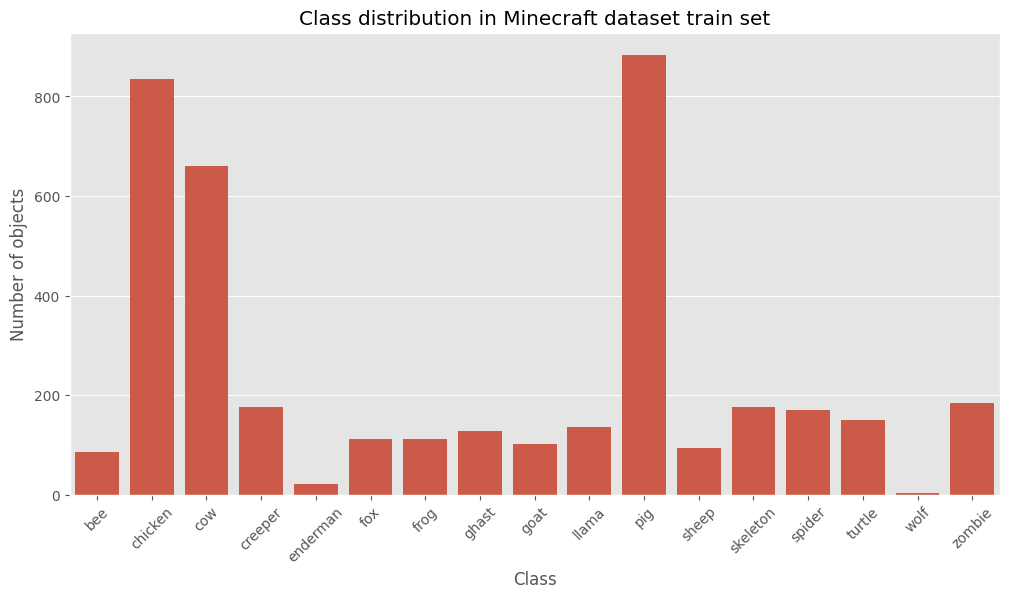

In [ ]:
# 7. Распределение классов train

class_counts_train = ann_df_train["category_id"].value_counts().sort_index()

class_names_train = {
    row["id"]: row["name"]
    for _, row in cat_df.iterrows()
}

class_labels = [class_names_train[i] for i in class_counts_train.index]

plt.figure(figsize=(12,6))
sns.barplot(x=class_labels, y=class_counts_train.values)

plt.xticks(rotation=45)
plt.title("Class distribution in Minecraft dataset train set")
plt.xlabel("Class")
plt.ylabel("Number of objects")

plt.show()

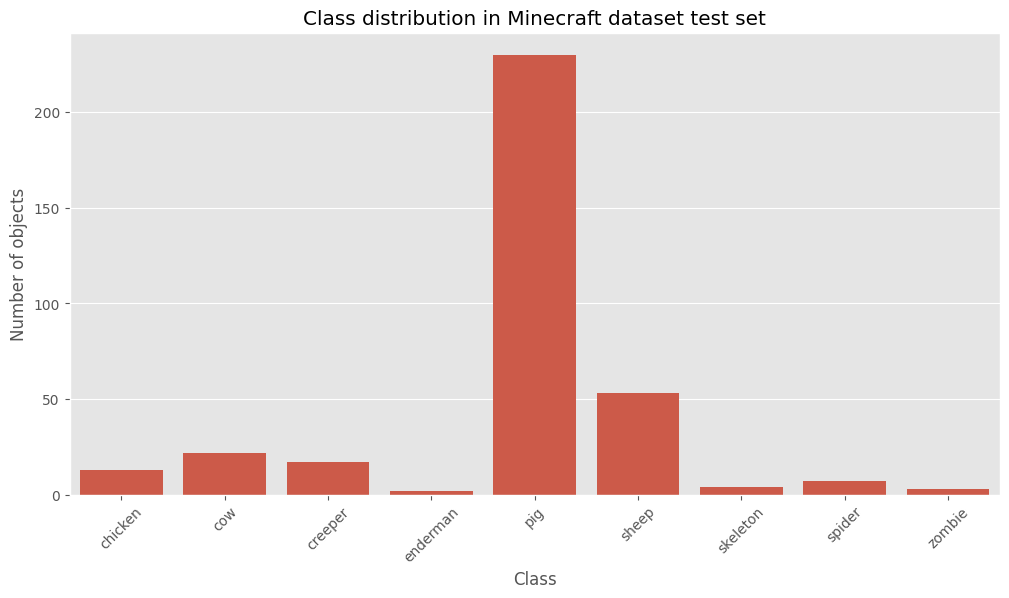

In [26]:
# 8. Распределение классов test

class_counts_test = ann_df_test["category_id"].value_counts().sort_index()

class_names_test = {
    row["id"]: row["name"]
    for _, row in cat_df.iterrows()
}

class_labels = [class_names_test[i] for i in class_counts_test.index]

plt.figure(figsize=(12,6))
sns.barplot(x=class_labels, y=class_counts_test.values)

plt.xticks(rotation=45)
plt.title("Class distribution in Minecraft dataset test set")
plt.xlabel("Class")
plt.ylabel("Number of objects")

plt.show()

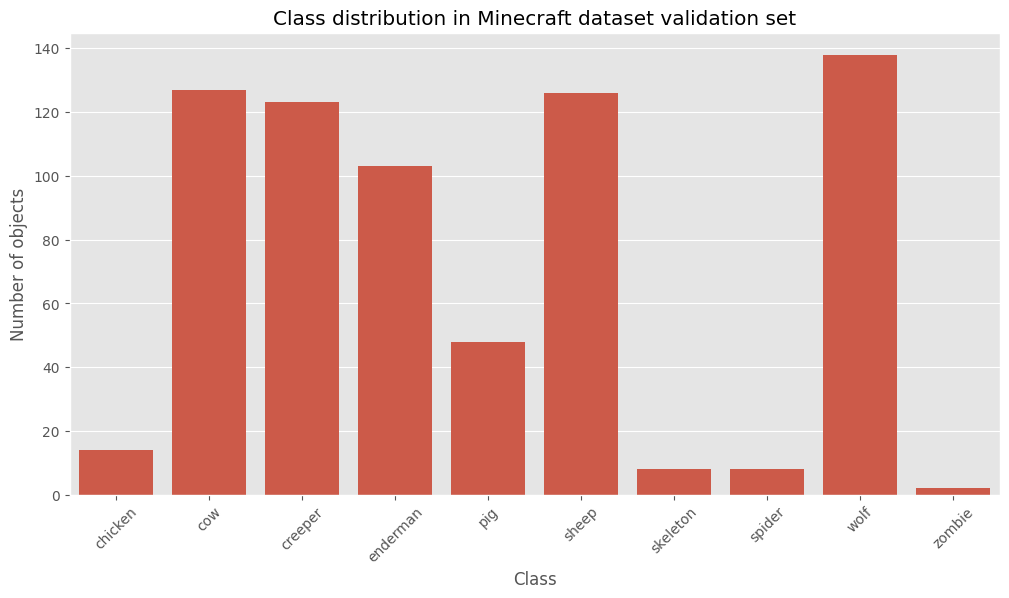

In [27]:
# 9. Распределение классов validation

class_counts_val = ann_df_val["category_id"].value_counts().sort_index()

class_names_val = {
    row["id"]: row["name"]
    for _, row in cat_df.iterrows()
}

class_labels = [class_names_val[i] for i in class_counts_val.index]

plt.figure(figsize=(12,6))
sns.barplot(x=class_labels, y=class_counts_val.values)

plt.xticks(rotation=45)
plt.title("Class distribution in Minecraft dataset validation set")
plt.xlabel("Class")
plt.ylabel("Number of objects")

plt.show()

In [30]:
# 8. Анализ дисбаланса классов train
print("Train set imbalance analysis:")
print("Max class count:", class_counts_train.max())
print("Min class count:", class_counts_train.min())

imbalance_ratio = class_counts_train.max() / class_counts_train.min()
print("Imbalance ratio:", imbalance_ratio)

Train set imbalance analysis:
Max class count: 884
Min class count: 4
Imbalance ratio: 221.0


In [31]:
# 9. Анализ дисбаланса классов validation
print("Validation set imbalance analysis:")
print("Max class count:", class_counts_val.max())
print("Min class count:", class_counts_val.min())

imbalance_ratio = class_counts_val.max() / class_counts_val.min()
print("Imbalance ratio:", imbalance_ratio)

Validation set imbalance analysis:
Max class count: 138
Min class count: 2
Imbalance ratio: 69.0


In [32]:
# 10. Анализ дисбаланса классов test
print("Test set imbalance analysis:")
print("Max class count:", class_counts_test.max())
print("Min class count:", class_counts_test.min())

imbalance_ratio = class_counts_test.max() / class_counts_test.min()
print("Imbalance ratio:", imbalance_ratio)

Test set imbalance analysis:
Max class count: 230
Min class count: 2
Imbalance ratio: 115.0


In [33]:
# 9. Визуализация bounding boxes
def draw_boxes(image, boxes, labels):

    image = image.copy()

    for box, label in zip(boxes, labels):

        x, y, w, h = box

        x1 = int(x)
        y1 = int(y)
        x2 = int(x + w)
        y2 = int(y + h)

        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            image,
            label,
            (x1, y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    return image

visualizing sample image with annotations train set:


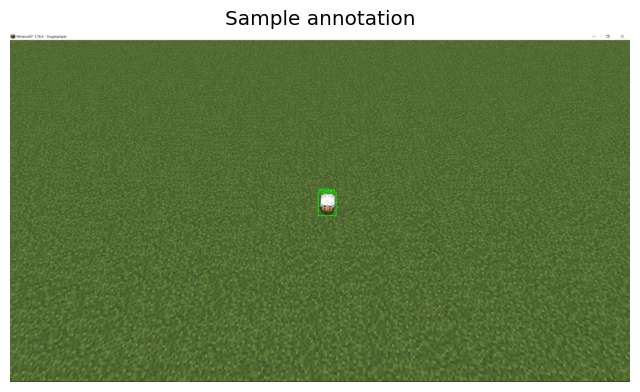

In [42]:
import json

print("visualizing sample image with annotations train set:")

train_ann_path = ann_dir / "annotations_train.json"

with open(train_ann_path, "r") as f:
    train_json = json.load(f)

sample_image_train = images_df_train.sample(1).iloc[0]

img_id = sample_image_train["id"]
file_name = sample_image_train["file_name"]

img_path = train_dir / file_name

image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample_annotations_train = ann_df_train[ann_df_train["image_id"] == img_id]

boxes = sample_annotations_train["bbox"].tolist()

# mapping id -> name
class_names_train = {
    cat["id"]: cat["name"]
    for cat in train_json["categories"]
}

labels = [
    class_names_train[cid]
    for cid in sample_annotations_train["category_id"]
]

vis_img = draw_boxes(image, boxes, labels)

plt.figure(figsize=(8,8))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Sample annotation")
plt.show()

Вывод: данные имеют сильный дисбаланс, который необходимо устранить след подходом 
4. Обработка дисбаланса классов

Oversampling редких классов:
увеличение количества изображений с редкими объектами
повторное использование изображений с редкими классами

Data augmentation
Для редких классов будет применено больше аугментаций:
повороты
изменение яркости
шум
масштабирование
случайные кропы

4.3 Взвешивание классов
Использование class weights или Focal Loss, чтобы модель больше учитывала редкие классы.


Эти правки будут вноиться только после того как вообще получится что то сделать 

c:\Users\Admin\NEIRO\SPR_5_FIN\mmdetection\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')


Backbone weights загружены, bbox_head готов к обучению на 17 классов
Inference сохранён в artifacts\inference\test_pretrained.jpg


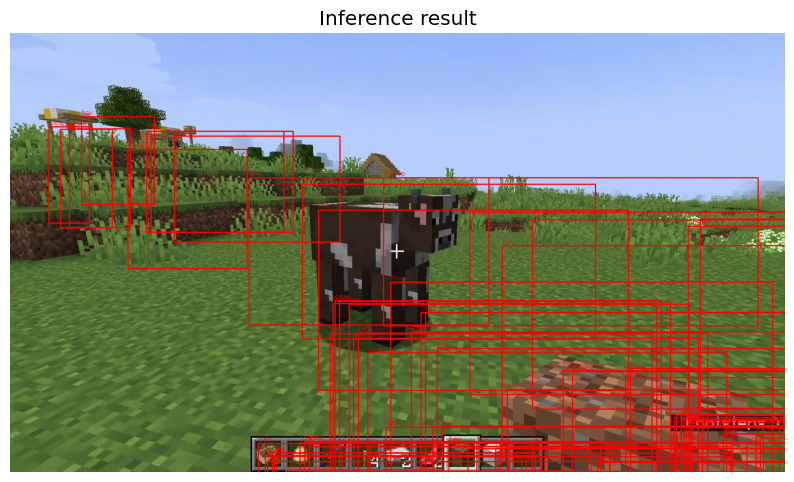

In [ ]:
# === Imports ===
import torch
from pathlib import Path
import mmcv
import cv2
import matplotlib.pyplot as plt
from mmdet.apis import init_detector, inference_detector

# Функция для отрисовки bbox и labels на изображении
def draw_boxes(image, boxes, labels, color=(255,0,0), thickness=2):
    img = image.copy()
    for bbox, label in zip(boxes, labels):
        x1, y1, w, h = bbox
        x2, y2 = int(x1 + w), int(y1 + h)
        cv2.rectangle(img, (int(x1), int(y1)), (x2, y2), color, thickness)
        cv2.putText(img, label, (int(x1), int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)
    return img

# === Конфиг и checkpoint ===
config_file = 'configs/fcos/fcos_minecraft.py'
checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'  # COCO pretrained

# === Проверяем изображение для теста ===
img_path = Path("datasets/minecraft/valid/tree-extracted00045_png.rf.cb6c69fe62a53e198b7c6d0d0aa99bb6.jpg")
assert img_path.exists(), f"{img_path} не найден!"

# === Инициализация модели на CPU ===
model = init_detector(config_file, device='cpu')

# === Загружаем pretrained веса backbone, исключая bbox_head ===
checkpoint = torch.load(checkpoint_file, map_location='cpu')['state_dict']
filtered_ckpt = {k: v for k, v in checkpoint.items() if not k.startswith('bbox_head')}
model.load_state_dict(filtered_ckpt, strict=False)
print("Backbone weights загружены, bbox_head готов к обучению на 17 классов")

# === Инференс ===
result = inference_detector(model, str(img_path))

# === Преобразуем результат в boxes и labels для matplotlib ===
# result — это DetDataSample, поэтому используем bbox и labels
# result.pred_instances.bboxes: tensor N x 4
# result.pred_instances.labels: tensor N
bboxes = result.pred_instances.bboxes.cpu().numpy()
labels_idx = result.pred_instances.labels.cpu().numpy()

# Названия классов (17 Minecraft)
CLASSES = (
    'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
    'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie'
)
labels = [CLASSES[i] for i in labels_idx]

# === Загружаем изображение через cv2 и конвертируем в RGB ===
image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# === Отрисовываем bounding boxes ===
vis_img = draw_boxes(image, bboxes, labels)

# === Сохраняем визуализацию ===
out_file = Path("artifacts/inference/test_pretrained.jpg")
out_file.parent.mkdir(parents=True, exist_ok=True)
mmcv.imwrite(vis_img, str(out_file))
print(f"Inference сохранён в {out_file}")

# === Показываем результат через matplotlib ===
plt.figure(figsize=(10,10))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Inference result")
plt.show()

c:\Users\Admin\NEIRO\SPR_5_FIN\mmdetection\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')


Backbone weights загружены, bbox_head готов к обучению на 17 классов
Inference сохранён в artifacts\inference\test_pretrained.jpg


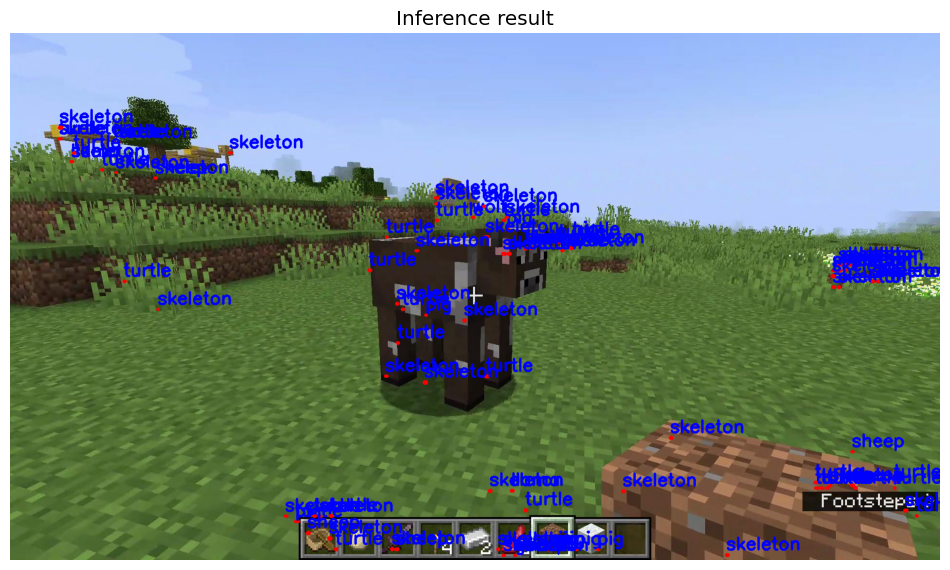

In [98]:
# === Imports ===
import torch
from pathlib import Path
import mmcv
import cv2
from mmdet.apis import init_detector, inference_detector
import numpy as np

# --- Функция для отрисовки bbox и labels ---
def draw_boxes(image, boxes, labels, box_color=(255,0,0), text_color=(0,0,255), thickness=2, font_scale=1.2):
    img = image.copy()
    for bbox, label in zip(boxes, labels):
        x1, y1, x2, y2 = bbox.astype(int)
        # рамка
        cv2.rectangle(img, (x1, y1), (x2, y2), color=box_color, thickness=thickness)
        # подпись
        cv2.putText(
            img,
            label,
            (x1, max(y1-10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            color=text_color,
            thickness=thickness
        )
    return img

# === Конфиг и checkpoint ===
config_file = 'configs/fcos/fcos_minecraft.py'
checkpoint_file = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'

# === Проверяем изображение ===
img_path = Path("datasets/minecraft/valid/tree-extracted00045_png.rf.cb6c69fe62a53e198b7c6d0d0aa99bb6.jpg")
assert img_path.exists(), f"{img_path} не найден!"

# === Инициализация модели на CPU ===
model = init_detector(config_file, device='cpu')

# === Загружаем pretrained веса backbone, исключая bbox_head ===
checkpoint = torch.load(checkpoint_file, map_location='cpu')['state_dict']
filtered_ckpt = {k: v for k, v in checkpoint.items() if not k.startswith('bbox_head')}
model.load_state_dict(filtered_ckpt, strict=False)
print("Backbone weights загружены, bbox_head готов к обучению на 17 классов")

# === Инференс ===
result = inference_detector(model, str(img_path))

# === Преобразуем результат в boxes и labels ===
bboxes = result.pred_instances.bboxes.cpu().numpy()
labels_idx = result.pred_instances.labels.cpu().numpy()
scores = result.pred_instances.scores.cpu().numpy()

# === Фильтруем по порогу уверенности ===
score_thr = 0.0
keep = scores >= score_thr
bboxes = bboxes[keep]
labels_idx = labels_idx[keep]

# --- Классы Minecraft ---
CLASSES = (
    'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
    'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie'
)
labels = [CLASSES[i] for i in labels_idx]

# === Загружаем изображение через cv2 и конвертируем в RGB ===
image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# === Отрисовываем bounding boxes с синими рамками и красными подписями ===
vis_img = draw_boxes(
    image,
    bboxes,
    labels,
    box_color=(255,0,0),   # синие рамки BGR
    text_color=(0,0,255),  # красный текст BGR
    thickness=3,
    font_scale=1.2
)

# === Сохраняем визуализацию ===
out_file = Path("artifacts/inference/test_pretrained.jpg")
out_file.parent.mkdir(parents=True, exist_ok=True)
mmcv.imwrite(vis_img, str(out_file))
print(f"Inference сохранён в {out_file}")

# === Показываем результат через matplotlib ===
import matplotlib.pyplot as plt
plt.figure(figsize=(12,12))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Inference result")
plt.show()

ModuleNotFoundError: No module named 'mmdet.datasets.builder'

c:\Users\Admin\NEIRO\SPR_5_FIN\mmdetection\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')


Number of predictions: 100


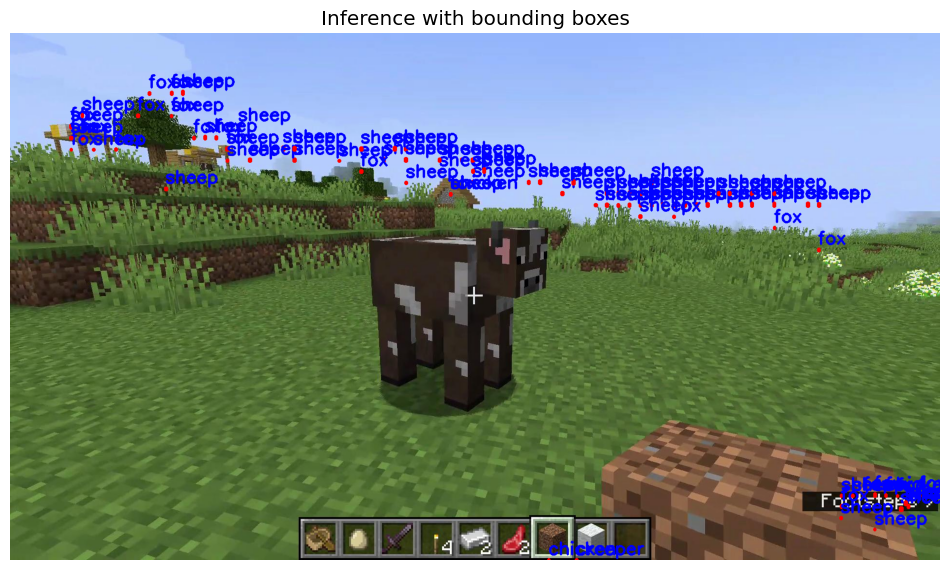

True

In [124]:
from mmdet.apis import init_detector, inference_detector
import cv2

# Загружаем модель
model = init_detector(cfg, device='cpu')

# Берем пример изображения
img_path = 'datasets/minecraft/valid/tree-extracted00045_png.rf.cb6c69fe62a53e198b7c6d0d0aa99bb6.jpg'

image = cv2.imread(img_path)
result = inference_detector(model, img_path)

# Проверяем количество предсказаний
bboxes = result.pred_instances.bboxes.cpu().numpy()
labels = result.pred_instances.labels.cpu().numpy()
print("Number of predictions:", len(bboxes))

import matplotlib.pyplot as plt

def draw_boxes(image, boxes, labels, box_color=(255,0,0), text_color=(0,0,255), thickness=3, font_scale=1.2):
    img = image.copy()
    for bbox, label in zip(boxes, labels):
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), color=box_color, thickness=thickness)
        cv2.putText(img, label, (x1, max(y1-10, 0)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, thickness)
    return img

# Конвертируем изображение в RGB (OpenCV читает в BGR)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Предположим у тебя 17 классов Minecraft
CLASSES = (
    'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
    'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie'
)

labels_text = [CLASSES[i] for i in labels]

vis_img = draw_boxes(image_rgb, bboxes, labels_text)

# Сохраняем и показываем
plt.figure(figsize=(12,12))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Inference with bounding boxes")
plt.show()

# Сохраняем
import mmcv
mmcv.imwrite(vis_img, "artifacts/inference/test_with_boxes.jpg")

In [123]:
from mmengine.config import Config
from mmdet.registry import RUNNERS

config_file = "configs/fcos/fcos_minecraft.py"

cfg = Config.fromfile(config_file)

cfg.work_dir = "./work_dirs/minecraft_fcos"

# обучение на CPU
cfg.device = "cpu"

runner = RUNNERS.build(cfg)

runner.train()

KeyError: "Duplicate key is not allowed among bases. Duplicate keys: {'optim_wrapper', 'test_cfg', 'param_scheduler', 'train_cfg', 'auto_scale_lr', 'val_cfg'}"